In [1]:

import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy import stats
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# sns.set_palette("colorblind")
# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [8]:

E003 = pd.read_csv('benchmarks/randomforest/results/E003_bs_bf_para_indicators.csv')
E116 = pd.read_csv('benchmarks/randomforest/results/E116_bs_bf_para_indicators.csv')
E118 = pd.read_csv('benchmarks/randomforest/results/E118_bs_bf_para_indicators.csv')

DeepBurst_results = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
DeepBurst_results['method'] = 'DeepBurst'
DeepBurst_results['auc'] = DeepBurst_results['auc'] / 100

data = pd.concat([E003, E116, E118,DeepBurst_results], axis=0).drop(columns=['acc'])
data


,eid,fold,target,method,auc
0,E003,1,bf_label,rf,0.925768
1,E003,1,bf_label,logit,0.912336
2,E003,1,bs_label,rf,0.798687
3,E003,1,bs_label,logit,0.779691
4,E003,2,bf_label,rf,0.926024
...,...,...,...,...,...
19,E003,1,bf_label,DeepBurst,0.940339
20,E003,2,bs_label,DeepBurst,0.823372
21,E003,2,bf_label,DeepBurst,0.936079
22,E003,3,bs_label,DeepBurst,0.812042


# txburst

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_50674/3293239668.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_50674/3293239668.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


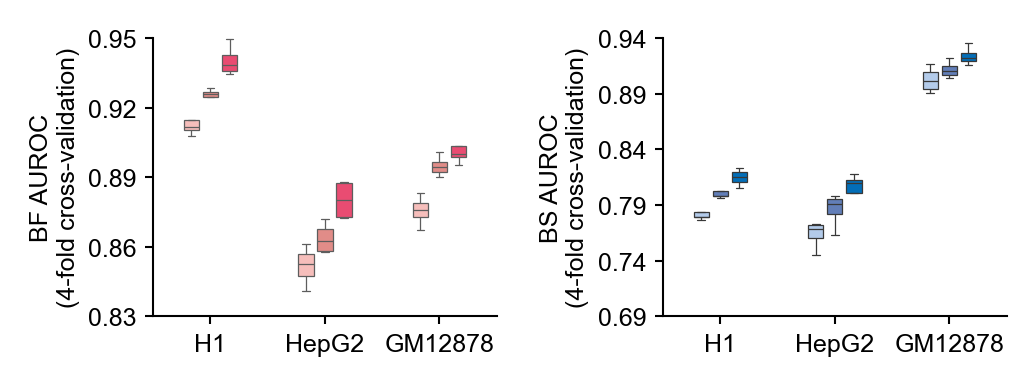

In [17]:
# 设置为 colorblind 调色板
fig, ax = plt.subplots(1, 2, figsize=(9/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = ['logit','rf','DeepBurst']

palette = ['#F6BEBB',"#E18C88","#E94C72"]
sns.boxplot(data=data[data['target']=='bf_label'], x='eid',y='auc',hue='method',fliersize=0, linewidth=0.3,ax=ax[0],order=order,hue_order=hue_order,
            gap=0.2,width=0.5,palette=palette,saturation=1)

palette = ['#B3CBEA',"#627EB8","#036EB8"]
sns.boxplot(data=data[data['target']=='bs_label'], x='eid',y='auc',hue='method',fliersize=0, linewidth=0.3,ax=ax[1],order=order,hue_order=hue_order,
            gap=0.2,width=0.5,palette=palette,saturation=1)

ax[0].set_ylim(bottom=0.83,top=0.95)
ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUROC\n(4-fold cross-validation)',)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_yticks([i/100 for i in range(83, 96, 3)],labels=[f"{i/100:.2f}"  for i in range(83, 96, 3)])


ax[1].set_ylabel(f'BS AUROC\n(4-fold cross-validation)',)
ax[1].set_ylim(bottom=0.69,top=0.94)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_yticks([i/100 for i in range(69, 95, 5)],labels=[f"{i/100:.2f}"  for i in range(69, 95, 5)])

plt.savefig('benchmarks/randomforest/figures/v7/Supplementary_figure12C.eps', format='eps', bbox_inches='tight')

# 显示图像
plt.show()

# DeepTX

In [20]:

E003 = pd.read_csv('benchmarks/baseline_classifiers/results/E003_bs_bf_para_deeptx_delay_1_indicators.csv')
E116 = pd.read_csv('benchmarks/baseline_classifiers/results/E116_bs_bf_para_deeptx_delay_1_indicators.csv')
E118 = pd.read_csv('benchmarks/baseline_classifiers/results/E118_bs_bf_para_deeptx_delay_1_indicators.csv')

DeepBurst_results = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
DeepBurst_results['method'] = 'DeepBurst'
DeepBurst_results['auc'] = DeepBurst_results['auc'] / 100

data = pd.concat([E003, E116, E118,DeepBurst_results], axis=0).drop(columns=['acc'])
data


,eid,fold,target,method,auc
0,E003,1,bf_label,rf,0.941210
1,E003,1,bf_label,logit,0.927475
2,E003,1,bs_label,rf,0.775179
3,E003,1,bs_label,logit,0.754585
4,E003,2,bf_label,rf,0.946528
...,...,...,...,...,...
19,E003,1,bf_label,DeepBurst,0.950631
20,E003,2,bs_label,DeepBurst,0.808145
21,E003,2,bf_label,DeepBurst,0.958888
22,E003,3,bs_label,DeepBurst,0.793926


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_50674/1459507505.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_50674/1459507505.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], )


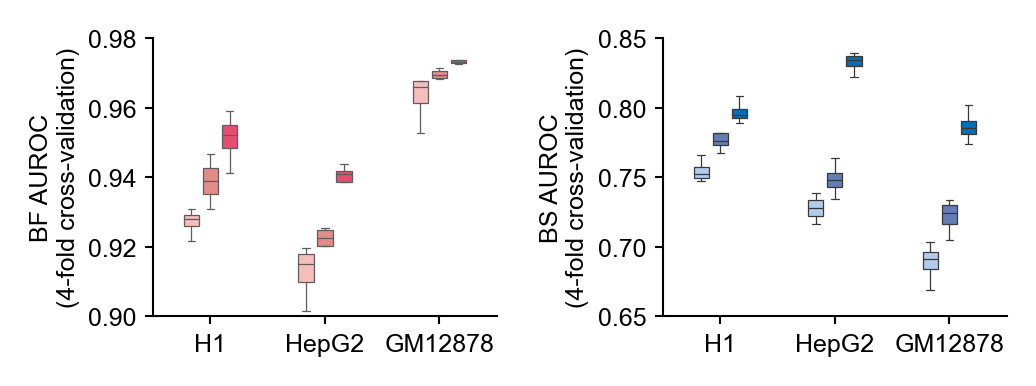

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(9/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = ['logit','rf','DeepBurst']

palette = ['#F6BEBB',"#E18C88","#E94C72"]
sns.boxplot(data=data[data['target']=='bf_label'], x='eid',y='auc',hue='method',fliersize=0, linewidth=0.3,ax=ax[0],order=order,hue_order=hue_order,
            gap=0.2,width=0.5,palette=palette,saturation=1)

palette = ['#B3CBEA',"#627EB8","#036EB8"]
sns.boxplot(data=data[data['target']=='bs_label'], x='eid',y='auc',hue='method',fliersize=0, linewidth=0.3,ax=ax[1],order=order,hue_order=hue_order,
            gap=0.2,width=0.5,palette=palette,saturation=1)

ax[0].set_ylim(bottom=0.90,top=0.98)
ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUROC\n(4-fold cross-validation)',fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_yticks([i/100 for i in range(90, 99, 2)],labels=[f"{i/100:.2f}"  for i in range(90, 99, 2)])


ax[1].set_ylabel(f'BS AUROC\n(4-fold cross-validation)',fontsize=6)
ax[1].set_ylim(bottom=0.65,top=0.85)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], )
ax[1].set_yticks([i/100 for i in range(65, 86, 5)],labels=[f"{i/100:.2f}" for i in range(65, 86, 5)])

plt.savefig('benchmarks/randomforest/figures/v7/Supplementary_figure13C.eps', format='eps', bbox_inches='tight')

# 显示图像
plt.show()